In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from visual_search import VisualSearchModel
from gist import Gist
from backbone import ConvGist, VGG
from torchvision.models import VGG16_Weights
from dataset_handler import COCODatasetHandler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

coco = COCODatasetHandler("../CoCo", "train2017")
IMG_SIZE = 224
BACKBONE_WEIGHTS_PATH = "models/best_convgist_model.pth"

Using device: cuda
loading annotations into memory...
Done (t=3.89s)
creating index...
index created!


In [38]:
target_batch = coco.find_instances("stop sign", 2, max_area=3000, min_area=2000, grayscale=False)
prototype = target_batch[0:2]
test_images = [target_batch[0]]

In [39]:

num_classes = 80
backbone = VGG(
    n_classes=num_classes,
    classifier="linear"
)
backbone.to(device)

model = VisualSearchModel(backbone, VGG16_Weights.DEFAULT.transforms(), device=str(device), img_size=(IMG_SIZE, IMG_SIZE))

transform = model.transform
print(transform)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [40]:
# Convert prototype list to PyTorch batch (directly from numpy, no PIL)
import torch.nn.functional as F

# Prepare batch data
batch_images = []
batch_bboxes = []

for instance in prototype:
    # Get image
    img = instance['image']
    
    # Convert PIL to numpy if needed
    if hasattr(img, 'convert'):  # PIL Image
        img = np.array(img)
    
    # Store original dimensions for bbox scaling
    orig_height, orig_width = img.shape[:2]
    img_tensor = torch.from_numpy(img).float().permute(2, 0, 1)/255
    img_tensor = transform(img_tensor)
    
    batch_images.append(img_tensor)
    
    # Transform bounding box coordinates from original to resized image space
    bbox_orig = instance['bbox_dict']
    scale_x = IMG_SIZE / orig_width
    scale_y = IMG_SIZE / orig_height
    
    bbox_transformed = {
        'x1': bbox_orig['x1'] * scale_x,
        'y1': bbox_orig['y1'] * scale_y,
        'x2': bbox_orig['x2'] * scale_x,
        'y2': bbox_orig['y2'] * scale_y
    }
    batch_bboxes.append(bbox_transformed)

# Stack into a batch tensor
prototype_batch = torch.stack(batch_images).to(device)
print(f"Prototype batch shape: {prototype_batch.shape}")
print(f"Number of bounding boxes: {len(batch_bboxes)}")
print(f"Example bbox (original → transformed): {instance['bbox_dict']} → {batch_bboxes[-1]}")

Prototype batch shape: torch.Size([2, 3, 224, 224])
Number of bounding boxes: 2
Example bbox (original → transformed): {'x1': 472.48, 'y1': 133.48, 'x2': 530.36, 'y2': 191.97} → {'x1': 165.368, 'y1': 62.29066666666666, 'x2': 185.626, 'y2': 89.586}


In [41]:
model.memorize_target_batch(prototype_batch, batch_bboxes, layer=29)

target1 = model.target_template
print(target1)

Memorized target from 2 instances
Response mean range: [0.0000, 8.9029]
Response variance range: [0.0000, 158.5220]
tensor([0.0000, 0.0000, 0.4025, 0.0000, 0.0000, 0.1903, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 6.4836, 0.0000, 0.0000, 0.0000, 1.9253, 0.0000, 6.3786,
        0.0000, 2.9350, 0.0000, 0.0000, 0.0000, 0.4440, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.2161, 2.7757, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        3.9131, 0.0000, 0.0000, 0.0000, 0.1082, 0.0000, 0.0000, 1.0638, 7.8536,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        1.6957, 3.9147, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 8.9002, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2397, 0.0000,
        0.0000, 0.0000, 1.7253, 0.0000, 1.4428, 0.0000, 0.0000, 0.0000, 0.0000,
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..4.456302].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..4.456302].


  Fixations: 3
    Fixation 1: (116, 44) - Distance: 179.7px
    Fixation 2: (130, 45) - Distance: 176.8px
    Fixation 3: (182, 52) - Distance: 172.6px
  Final distance to target: 172.6 pixels


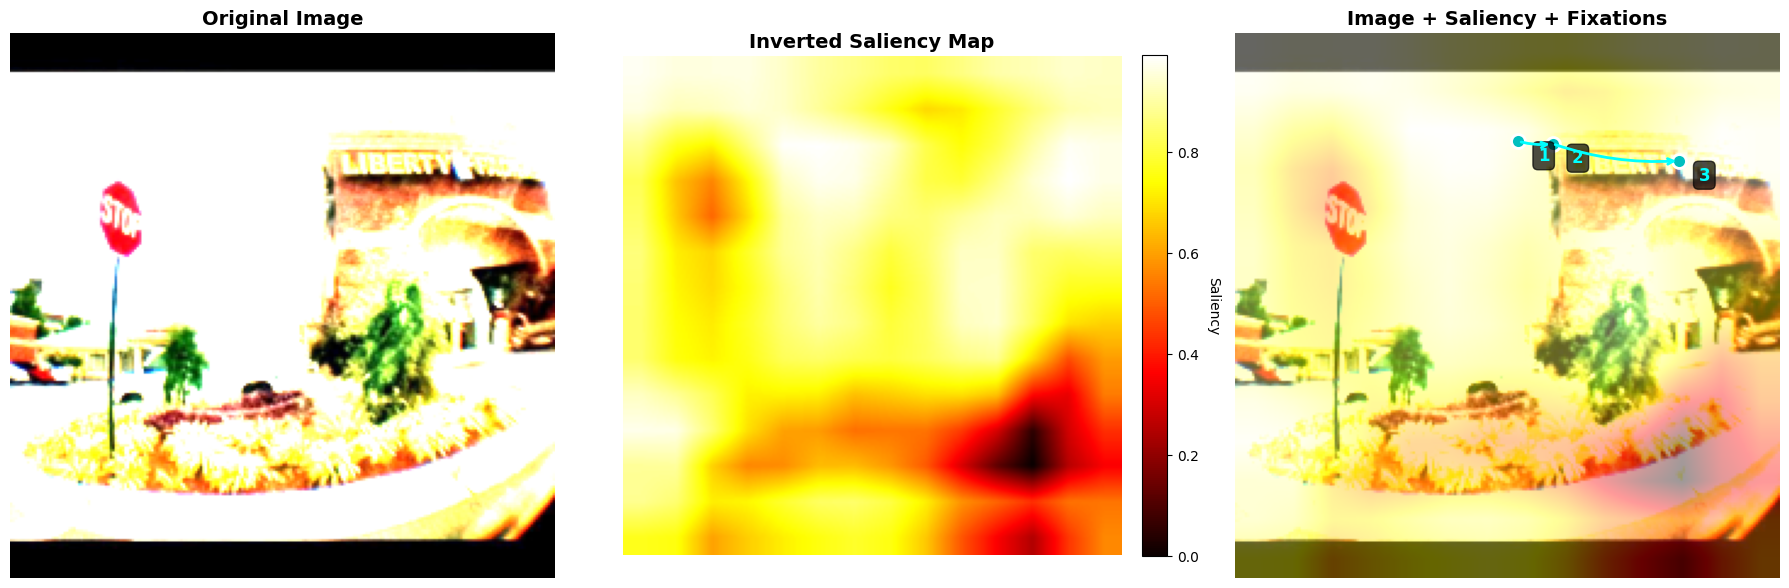

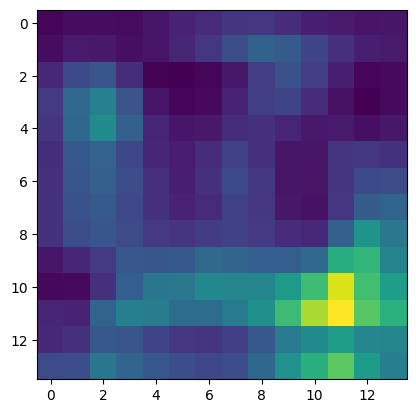

In [42]:
for idx, test_image in enumerate(test_images):
    bbox = test_image["bbox_dict"]
    target_location = (int((bbox['x1'] + bbox['x2']) / 2), int((bbox['y1'] + bbox['y2']) / 2))

    image = torch.Tensor(np.array(test_image["image"])).permute(2, 0, 1).to(device)
    image = model.transform(image)
    saliency, saliency_upsampled, fixations = model.visual_search(image)

    # Calculate performance metrics
    final_fixation = fixations[-1]
    distance_to_target = np.sqrt(
        (final_fixation[0] - target_location[0])**2 +
        (final_fixation[1] - target_location[1])**2
    )

    print(f"  Fixations: {len(fixations)}")
    for i, (x, y) in enumerate(fixations):
        dist = np.sqrt((x - target_location[0])**2 + (y - target_location[1])**2)
        print(f"    Fixation {i+1}: ({x}, {y}) - Distance: {dist:.1f}px")

    print(f"  Final distance to target: {distance_to_target:.1f} pixels")

    # Visualize results
    model.visualize_search(image, saliency_upsampled.squeeze(0), fixations)
    plt.figure()
    plt.imshow(saliency.detach().cpu().numpy().squeeze(0))
    plt.show()

In [43]:
img = prototype[0]['image']
    
# Convert PIL to numpy if needed
if hasattr(img, 'convert'):  # PIL Image
    img = np.array(img)

# Store original dimensions for bbox scaling
orig_height, orig_width = img.shape[:2]
image = torch.Tensor(np.array(img)).permute(2, 0, 1).to(device)
image = model.transform(image)

# Transform bounding box coordinates from original to resized image space
bbox_orig = prototype[0]['bbox_dict']
scale_x = IMG_SIZE / orig_width
scale_y = IMG_SIZE / orig_height

bbox_transformed = {
    'x1': bbox_orig['x1'] * scale_x,
    'y1': bbox_orig['y1'] * scale_y,
    'x2': bbox_orig['x2'] * scale_x,
    'y2': bbox_orig['y2'] * scale_y
}

{'x1': 126.16, 'y1': 181.62, 'x2': 169.76, 'y2': 261.17}


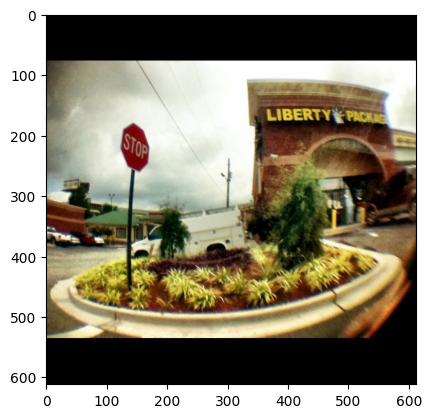

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..4.456302].


{'x1': 46.17620915032679, 'y1': 66.47529411764705, 'x2': 62.134379084967314, 'y2': 95.5916339869281}


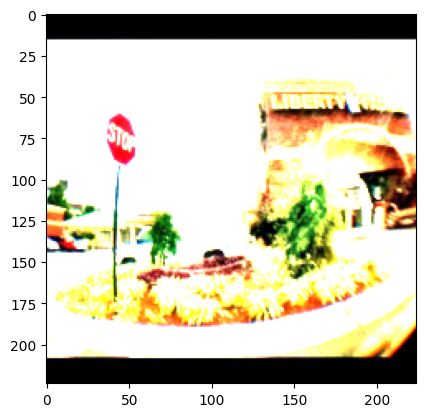

In [44]:
print(bbox_orig)

plt.figure()
plt.imshow(img)
plt.show()


print(bbox_transformed)

plt.figure()
plt.imshow(image.cpu().numpy().transpose(1,2,0)/255)

In [45]:
model.memorize_target(image, bbox_transformed, layer=29)
target2 = model.target_template

print(target2)

tensor([   0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000, 1351.2087,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000, 2281.7800,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,  156.0547,    0.0000,    0.0000,
           0.0000, 1059.2886,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000, 1439.3383,
           0.0000,    0.0000,    0.0000,    0.0000,    0.0000,    0.0000,
           0.0000,    0.0000,    0.000

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..4.456302].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..4.456302].


  Fixations: 3
    Fixation 1: (54, 92) - Distance: 159.0px
    Fixation 2: (55, 88) - Distance: 161.7px
    Fixation 3: (55, 88) - Distance: 161.7px
  Final distance to target: 161.7 pixels


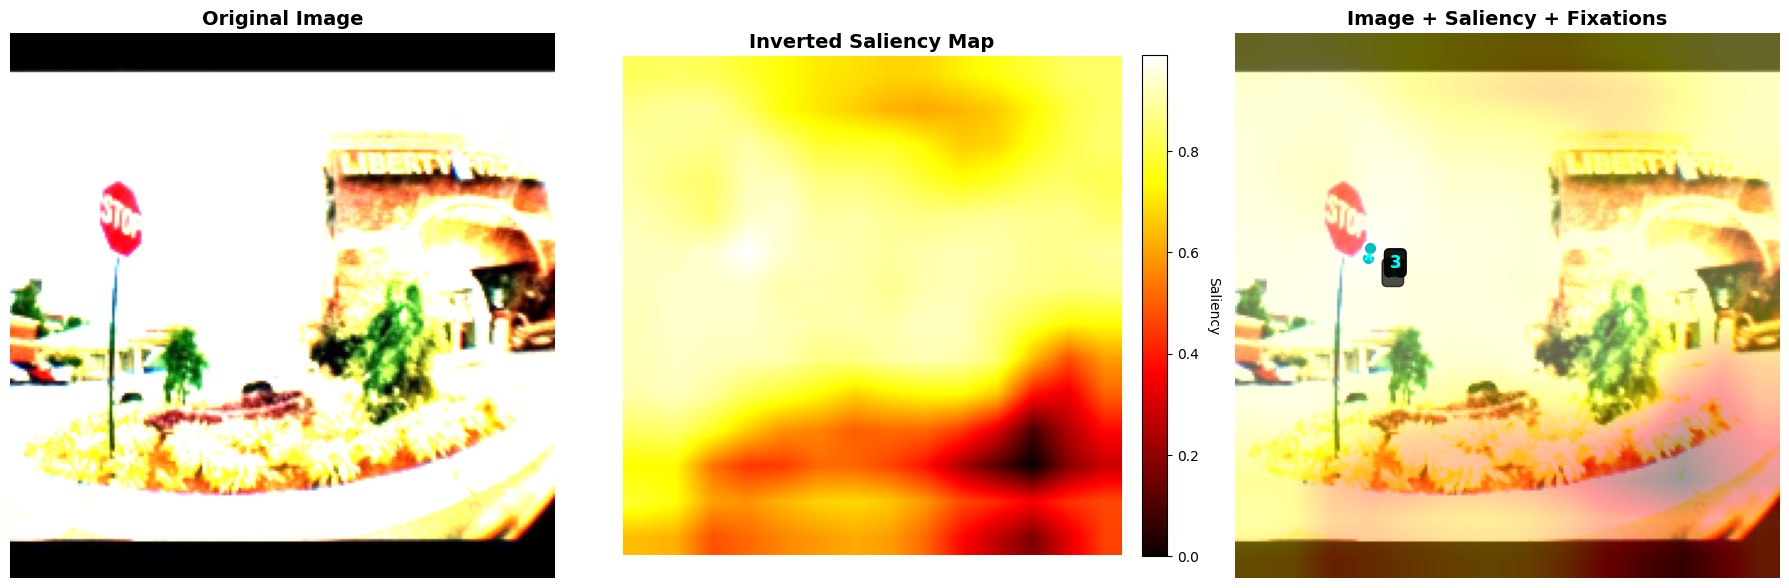

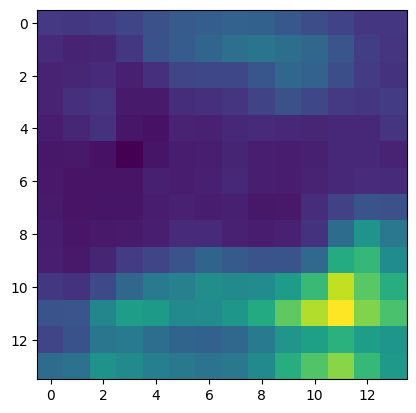

In [46]:
bbox = bbox_orig
target_location = (int((bbox['x1'] + bbox['x2']) / 2), int((bbox['y1'] + bbox['y2']) / 2))

saliency, saliency_upsampled, fixations = model.visual_search(image)

# Calculate performance metrics
final_fixation = fixations[-1]
distance_to_target = np.sqrt(
    (final_fixation[0] - target_location[0])**2 +
    (final_fixation[1] - target_location[1])**2
)

print(f"  Fixations: {len(fixations)}")
for i, (x, y) in enumerate(fixations):
    dist = np.sqrt((x - target_location[0])**2 + (y - target_location[1])**2)
    print(f"    Fixation {i+1}: ({x}, {y}) - Distance: {dist:.1f}px")

print(f"  Final distance to target: {distance_to_target:.1f} pixels")

# Visualize results
model.visualize_search(image, saliency_upsampled.squeeze(0), fixations)
plt.figure()
plt.imshow(saliency.detach().cpu().numpy().squeeze(0))
plt.show()